# Rehan Khan || 221A059 || 21

In [2]:
print("Rehan Khan || 221A059")
!pip install gymnasium[atari]
!pip install ale.py
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

Rehan Khan || 221A059


In [3]:
print("Rehan Khan || 221A059")
class DQN(nn.Module):
  def __init__(self, input_shape, n_actions):
    super().__init__()
    self.net = nn.Sequential(
      nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4),
      nn.ReLU(),
      nn.Conv2d(32, 64, kernel_size=4, stride=2),
      nn.ReLU(),
      nn.Conv2d(64, 64, kernel_size=3, stride=1),
      nn.ReLU(),
      nn.Flatten(),
      nn.Linear(3136, 512),
      nn.ReLU(),
      nn.Linear(512, n_actions)
    )

  def forward(self, x):
    return self.net(x / 255.0)

Rehan Khan || 221A059


In [4]:
print("Rehan Khan || 221A059")
class ReplayBuffer:
  def __init__(self, capacity):
    self.buffer = deque(maxlen=capacity)

  def push(self, state, action, reward, next_state, done):
    self.buffer.append((state, action, reward, next_state, done))

  def sample(self, batch_size):
    batch = random.sample(self.buffer, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    return (np.array(states),np.array(actions),np.array(rewards),np.array(next_states),np.array(dones))
  def __len__(self):
    return len(self.buffer)

Rehan Khan || 221A059


In [5]:
print("Rehan Khan || 221A059")
BATCH_SIZE = 32
GAMMA = 0.99
LR = 1e-4
BUFFER_SIZE = 100000
EPSILON_START = 1.0
EPSILON_END = 0.1
EPSILON_DECAY = 100000
TARGET_UPDATE = 1000

Rehan Khan || 221A059


##  Environment Setup

In [6]:
print("Rehan Khan || 221A059")
import ale_py

env = gym.make("ALE/Pong-v5", render_mode=None)
n_actions = env.action_space.n

# Example input shape for Atari (stacked frames)
input_shape = (4, 84, 84)

Rehan Khan || 221A059


## Initialize Network

In [7]:
print("Rehan Khan || 221A059")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

policy_net = DQN(input_shape, n_actions).to(device)
target_net = DQN(input_shape, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
replay_buffer = ReplayBuffer(BUFFER_SIZE)

Rehan Khan || 221A059


## Epsilon Greedy Policy

In [8]:
print("Rehan Khan || 221A059")

def epsilon_by_frame(frame_idx):
    return EPSILON_END + (EPSILON_START - EPSILON_END) * \
           np.exp(-1. * frame_idx / EPSILON_DECAY)

def select_action(state, epsilon):
    if random.random() < epsilon:
        return random.randrange(n_actions)
    else:
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        q_values = policy_net(state)
        return q_values.max(1)[1].item()

Rehan Khan || 221A059


## Training Setup

In [9]:
print("Rehan Khan || 221A059")
def train_step():
  if len(replay_buffer) < BATCH_SIZE:
      return
  states, actions, rewards, next_states, dones = replay_buffer.sample(BATCH_SIZE)
  states = torch. tensor(states, dtype=torch. float32).to(device)
  next_states = torch.tensor(next_states, dtype=torch. float32).to(device)
  actions = torch.tensor(actions).unsqueeze(1).to(device)
  rewards = torch.tensor(rewards).to(device)
  dones = torch. tensor(dones).to(device)
  q_values = policy_net(states).gather(1, actions).squeeze(1)
  next_q_values = target_net(next_states).max(1) [0]

  expected_q = rewards + GAMMA * next_q_values * (1 - dones.float())

  loss = nn.MSELoss() (q_values, expected_q.detach())

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Rehan Khan || 221A059


In [10]:
print("Rehan Khan || 221A059")
env = gym.make("ALE/Pong-v5", render_mode="rgb_array")

Rehan Khan || 221A059


In [11]:
print("Rehan Khan || 221A059")
env.reset ()

Rehan Khan || 221A059


(array([[[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [109, 118,  43],
         [109, 118,  43],
         [109, 118,  43]],
 
        [[109, 118,  43],
         [109, 118,  43],
         [109, 118,  43],
         ...,
         [109, 118,  43],
         [109, 118,  43],
         [109, 118,  43]],
 
        [[109, 118,  43],
         [109, 118,  43],
         [109, 118,  43],
         ...,
         [109, 118,  43],
         [109, 118,  43],
         [109, 118,  43]],
 
        ...,
 
        [[ 53,  95,  24],
         [ 53,  95,  24],
         [ 53,  95,  24],
         ...,
         [ 53,  95,  24],
         [ 53,  95,  24],
         [ 53,  95,  24]],
 
        [[ 53,  95,  24],
         [ 53,  95,  24],
         [ 53,  95,  24],
         ...,
         [ 53,  95,  24],
         [ 53,  95,  24],
         [ 53,  95,  24]],
 
        [[ 53,  95,  24],
         [ 53,  95,  24],
         [ 53,  95,  24],
         ...,
         [ 53,  95,  24],
  

Rehan Khan || 221A059


array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [109, 118,  43],
        [109, 118,  43],
        [109, 118,  43]],

       [[109, 118,  43],
        [109, 118,  43],
        [109, 118,  43],
        ...,
        [109, 118,  43],
        [109, 118,  43],
        [109, 118,  43]],

       [[109, 118,  43],
        [109, 118,  43],
        [109, 118,  43],
        ...,
        [109, 118,  43],
        [109, 118,  43],
        [109, 118,  43]],

       ...,

       [[ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24],
        ...,
        [ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24]],

       [[ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24],
        ...,
        [ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24]],

       [[ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24],
        ...,
        [ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24]]], dtype=uint8)
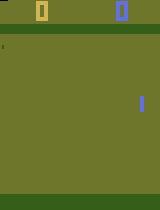

In [12]:
print("Rehan Khan || 221A059")
env.render()